# White light CCF of HD 189733

In this notebook, we present a simple example of the application of the Doppler Shadow technique to ESPRESSO observations of HD 189733, a K1V star, extracting the white light CCF provided by the DRS.

In [1]:
import numpy as np

from HECATE.HECATE import HECATE   # main class

from HECATE.get_data import *      # to retrieve the data
from HECATE.plots import *         # to plot the airmass and SNR

Warming up JIT-compiled functions...


Below we list the stellar, planetary and orbital parameters, as used in Cristo et al. (2024) and Gonçalves et al. (2026).

In [2]:
stellar_params = {
                "Teff":4969, "Teff_err":43,   #effective temperature [K]
                "logg":4.60, "logg_err":0.01, #superficial gravity [dex]
                "FeH":-0.07, "FeH_err":0.02,  #metallicity [dex]
                "P_rot":2.21857312,           #rotation period [d]
                "R_star":0.766,               #radius [solar radii]
                "inc_star":71.87              #stellar inclination [º]
                }

planet_params = {
                "P_orb":2.21857312,           #orbital period [d]
                "a_R":8.76863,                #system scale [stellar radii]
                "Rp_Rs":0.1602,               #planet-to-star radius ratio 
                "t0":53988.30339,             #mid-transit time [d]
                "e":0,                        #orbital eccentricity
                "w":90,                       #argument of periastron [º]
                "inc_planet":85.465,          #planet inclination [º]
                "lbda":-1.00,                 #spin-orbit angle [º]
                "dfp": -0.002424              #mid-transit phase shift, night of 2021-09-11
                }

Now we extract the CCFs from the example data provided.

Updating server file list:   0%|          | 0/9 [00:00<?, ?it/s]

Need to download 11 files, approximately 3.67 MB


LDTk downloading uncached files:   0%|          | 0/11 [00:00<?, ?it/s]

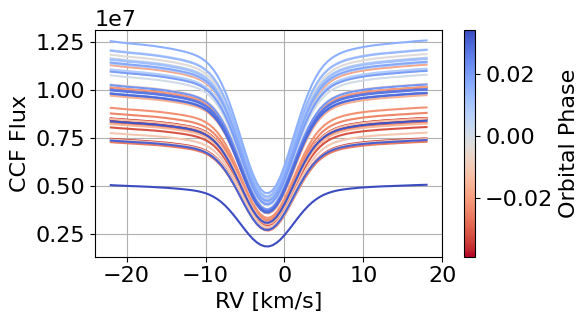

In [3]:
CCFs, time, airmass, berv, bervmax, snr, list_ccfs = get_CCFs(planet_params, stellar_params,
                                                              day='2021-08-11', 
                                                              directory_path="HD189733_ESPRESSO_white_light_ccfs")

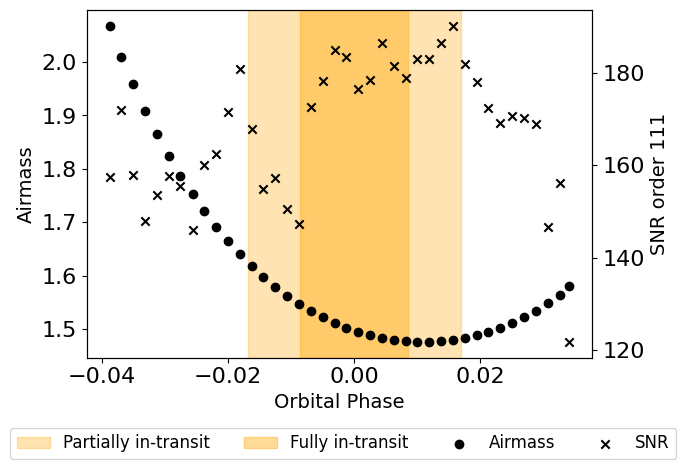

In [4]:
plot_air_snr(planet_params, stellar_params, time, airmass, snr)

Now we call an instance of HECATE, giving the parameters and data, where the simulation of the transit with SOAP will take place.

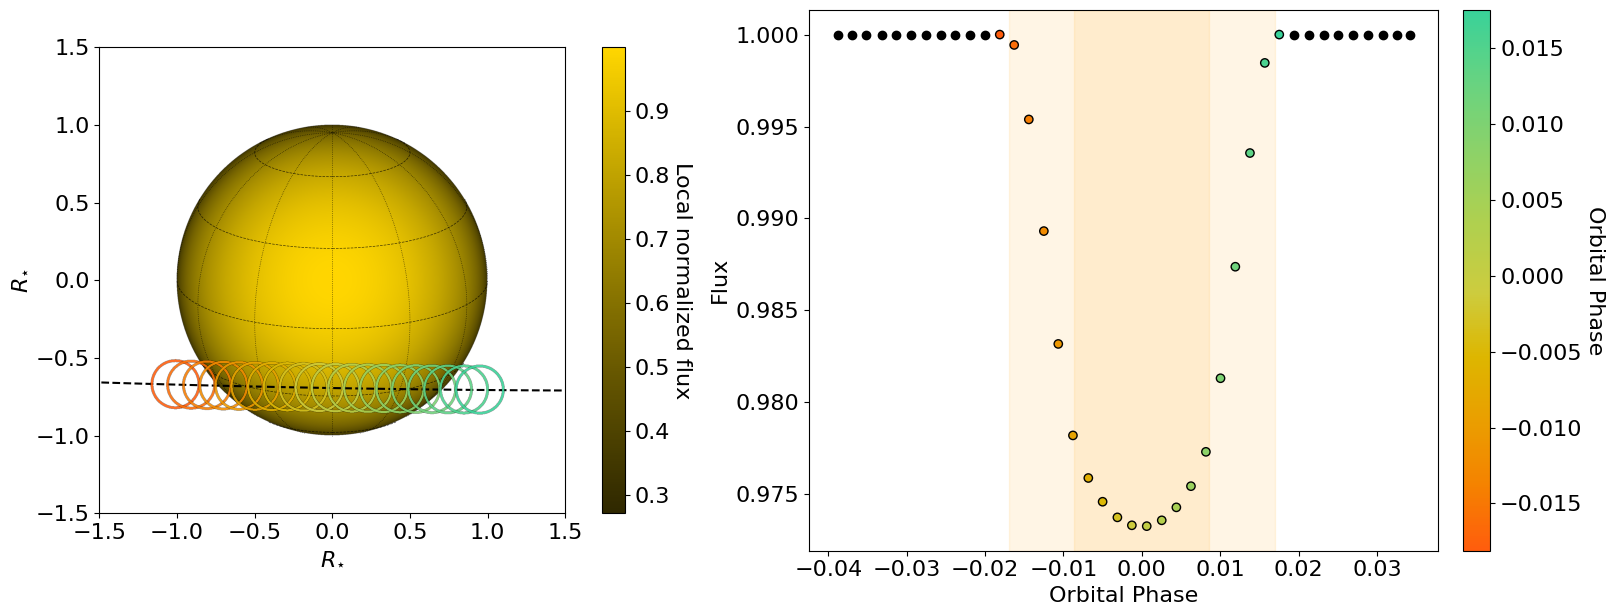

In [5]:
hecate = HECATE(planet_params, stellar_params, time, CCFs, spectra=None, plot_soap="SOAP")

To extract the local CCF, we just need to select the model to fit, the CCF type and the options for plotting.

In [6]:
plot = {"fits_initial_CCF":False,         # plot the initial fits to the CCFs
        "sys_vel_ccf":True,               # plot the systemic velocity of the star in the CCFs
        "master_out_of_transit":False,    # plot the master out-of-transit CCF
        "local_CCFs":True,                # plot the local CCFs
        "photometrical_rescale":False     # if the local CCFs are rescaled by the photometric transit model
        }

ccf_type = "white light"
model_fit = "modified Gaussian"

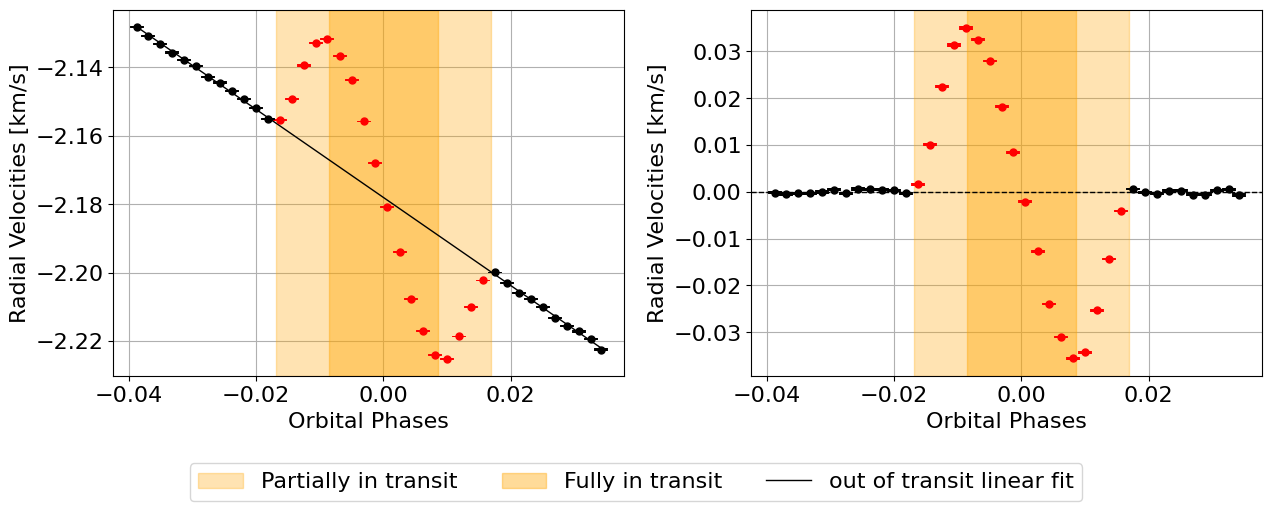

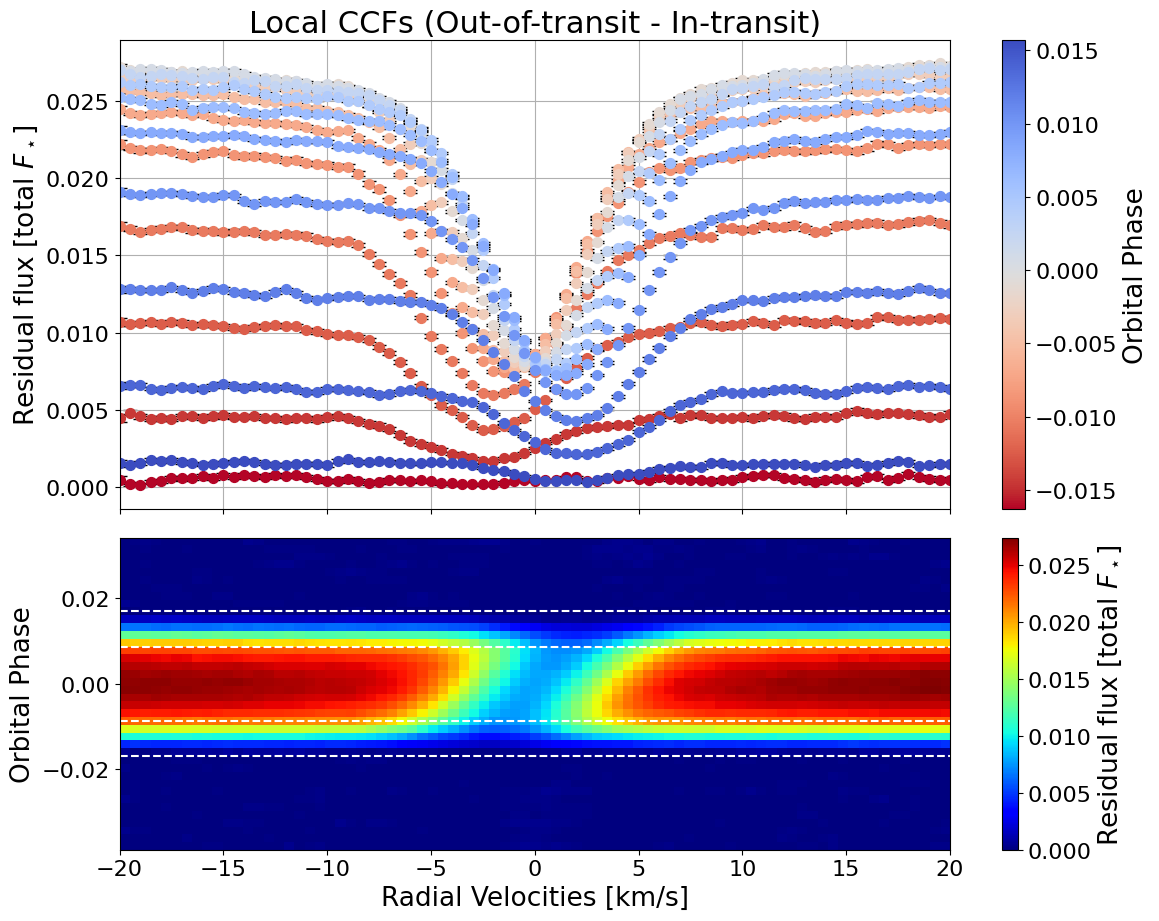

In [7]:
local_data = hecate.extract_local_CCF(model_fit, plot, save=None)

Tah-dah! We have the local white-light CCFs.

Now we can use HECATE to fit a profile to them, and extract the local parameters (central RV, line-center intensity, line-width measure) in function of $\mu$ or $\phi$.

##################################################
Fitting modified Gaussian model to master CCF profile
--------------------------------------------------
Fit parameters:
y0 = 0.999697 ± 0.000005
x0 = -0.000300 ± 0.000049
sigma = 3.404600 ± 0.000090
a = 0.629519 ± 0.000011
c = 1.823841 ± 0.000085
R^2:  0.9983
--------------------------------------------------
Profile parameters:
Central RV [km/s]: -0.000300 ± 0.000049
Continuum: 0.999697 ± 0.000005
Line-center intensity [%]: 37.028979 ± 0.001098
Line-width measure [km/s]: 3.404600 ± 0.000090


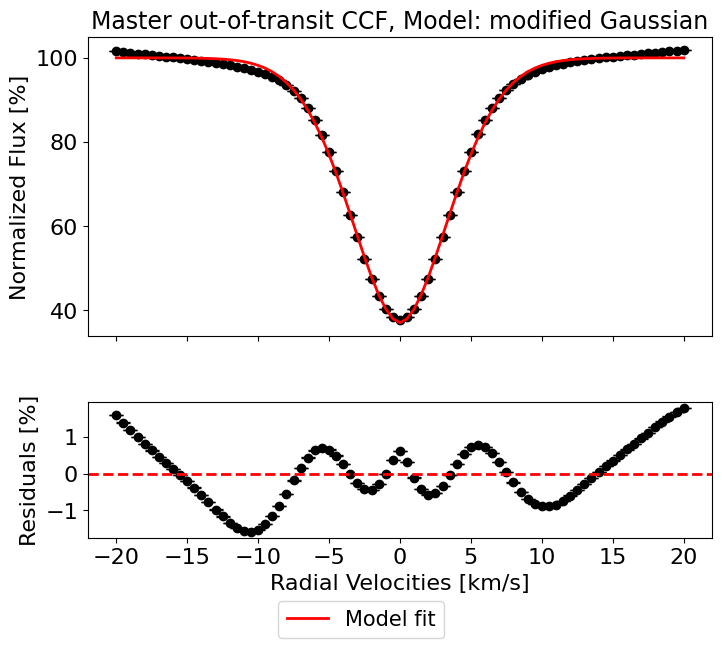

In [8]:
master_results = hecate.get_profile_parameters(profiles=local_data['master_out_of_transit_CCF'], 
                                               data_type="CCF", 
                                               observation_type="master", 
                                               model="modified Gaussian", 
                                               print_output=True, 
                                               plot_fit=True)

In [9]:
local_results = hecate.get_profile_parameters(profiles=local_data['local_CCFs'], 
                                              data_type="CCF", 
                                              observation_type="local", 
                                              model="modified Gaussian", 
                                              print_output=False, 
                                              plot_fit=False)

Having all the fits, we select the data based on quality -- $R^2 > 0.95$ and $\mu \geq 0.3$.

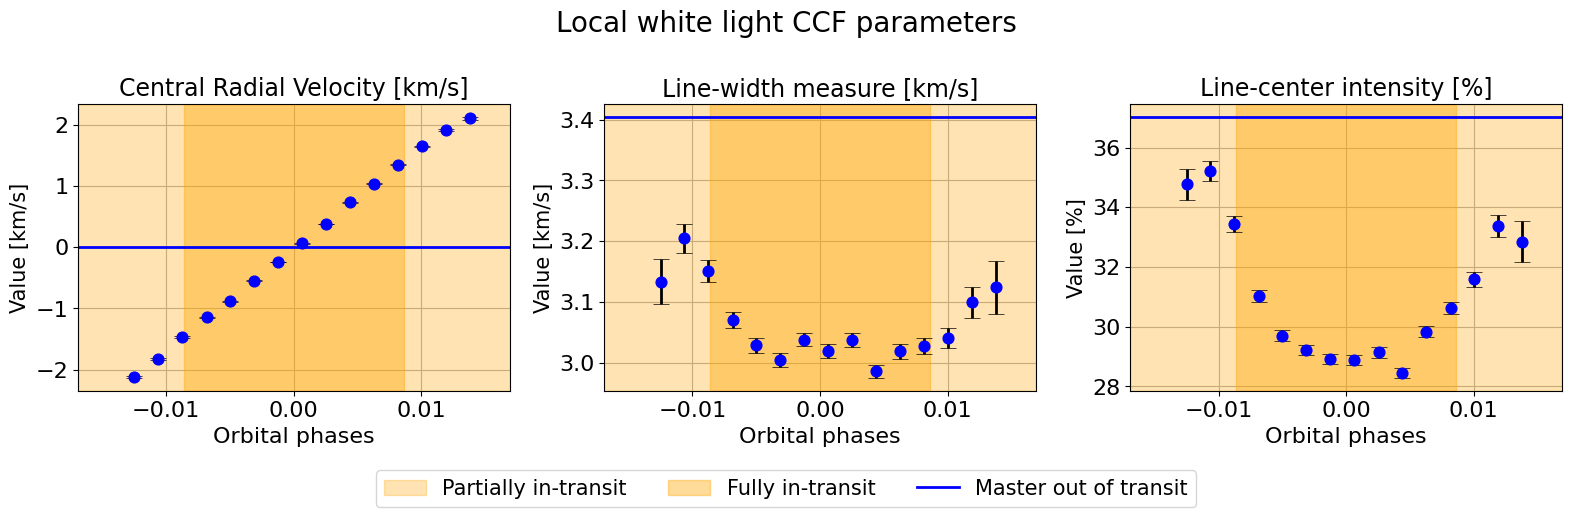

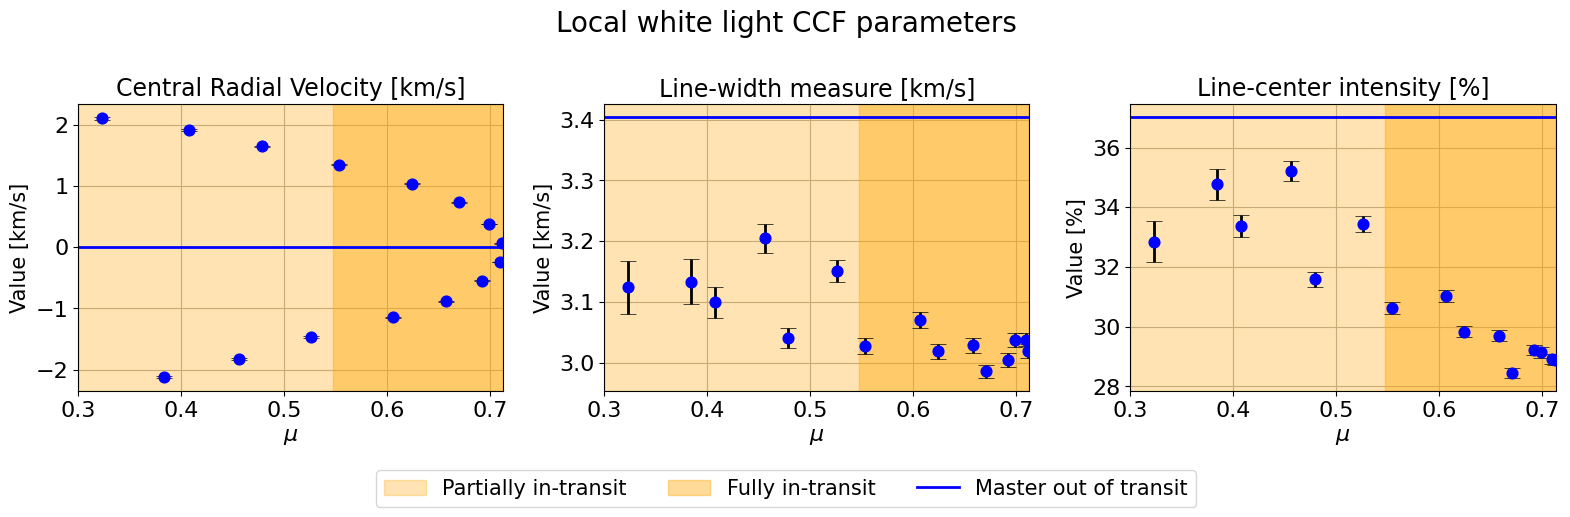

In [10]:
indices_final = np.array(list(set(np.where(local_results['R2'] >= 0.95)[0]).intersection(set(np.where(hecate.mu_in >= 0.3)[0]))))

local_params = [local_results['central_rv'], local_results['width'], local_results['intensity']]
master_params = [master_results['central_rv'], master_results['width'], master_results['intensity']]

hecate.plot_local_params(indices_final, local_params, master_params, suptitle=r"Local white light CCF parameters")

We can fit a linear model via nested sampling by running the same function.

Central Radial Velocity [km/s]
----------------------------------------
Orbital phases


0it [00:00, ?it/s]

269it [00:00, 2688.96it/s, batch: 0 | bound: 0 | nc: 1 | ncall: 358 | eff(%): 31.352 | loglstar:   -inf < -13773.087 <    inf | logz: -13780.533 +/-  0.122 | dlogz: 14343.316 >  0.010]

538it [00:00, 2549.79it/s, batch: 0 | bound: 0 | nc: 2 | ncall: 991 | eff(%): 36.083 | loglstar:   -inf < -641.181 <    inf | logz: -649.164 +/-  0.126 | dlogz: 705.547 >  0.010]      

794it [00:00, 2486.25it/s, batch: 0 | bound: 0 | nc: 1 | ncall: 1946 | eff(%): 32.461 | loglstar:   -inf < -80.605 <    inf | logz: -87.705 +/-  0.112 | dlogz: 103.461 >  0.010] 

...

16240it [00:23, 618.40it/s, batch: 7 | bound: 5 | nc: 23 | ncall: 339194 | eff(%):  4.631 | loglstar: -12.439 < -7.261 < -7.229 | logz: -18.079 +/-  0.090 | stop:  1.155]

16347it [00:23, 739.15it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 340731 | eff(%):  4.642 | loglstar: -12.439 < -7.208 < -7.229 | logz: -18.079 +/-  0.090 | stop:  1.155] 

16805it [00:23, 1347.75it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 341189 | eff(%):  4.772 | loglstar: -12.439 < -6.861 < -7.229 | logz: -18.079 +/-  0.090 | stop:  0.896]

16805it [00:23, 702.16it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 341189 | eff(%):  4.772 | loglstar: -12.439 < -6.861 < -7.229 | logz: -18.079 +/-  0.090 | stop:  0.896] 

Positive vs Negative slope
logZ(m>0)  = -31.161 ± 0.085
logZ(m<0)  = -18.079 ± 0.080
log Bayes factor = 13.082
Negative slope favored.
Linear fit parameters:
m = -16.218185 +/- 2.272270
b = 40.334972 +/- 1.370246
ln_f = -3.455295 +/- 0.219484
------------------------------


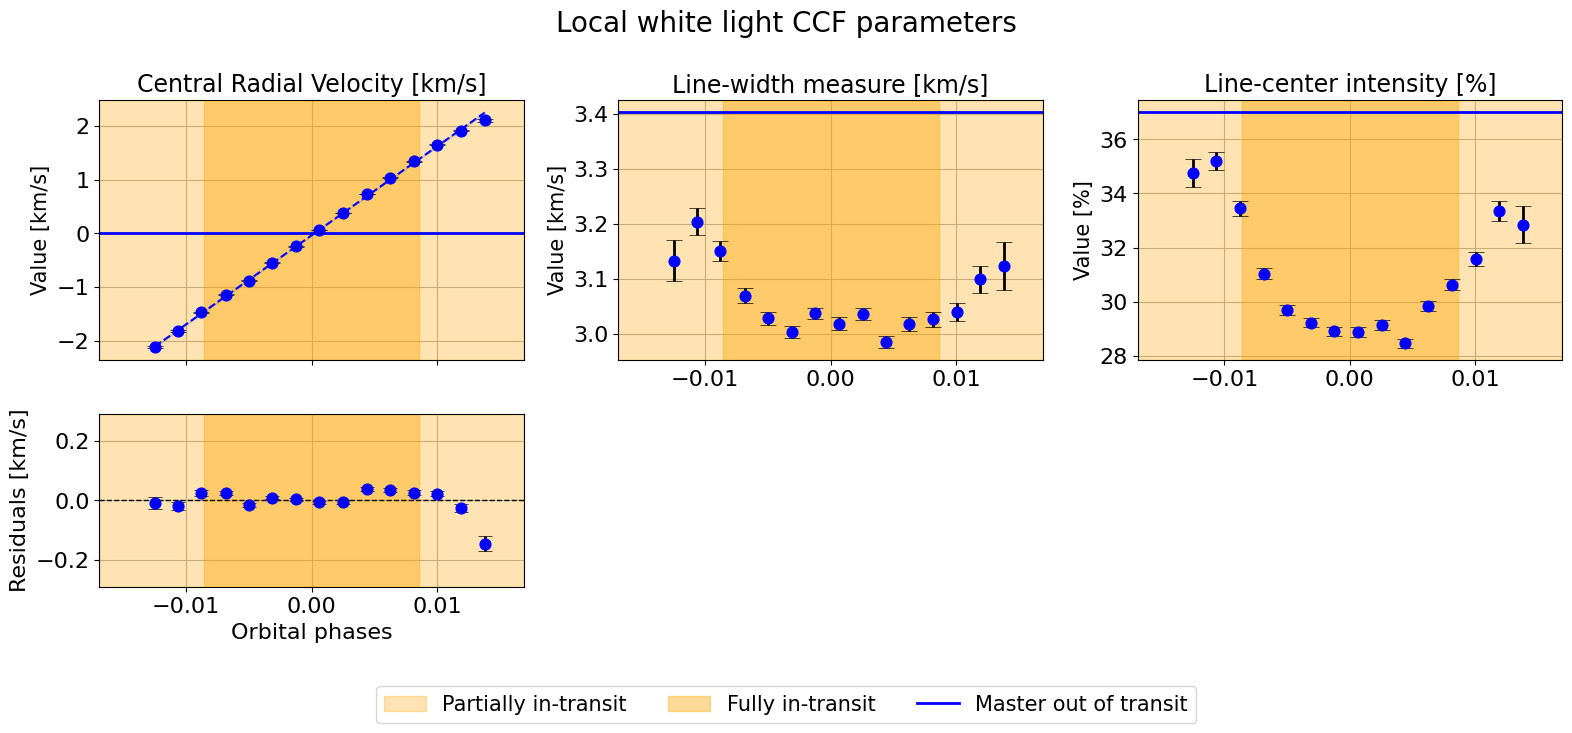

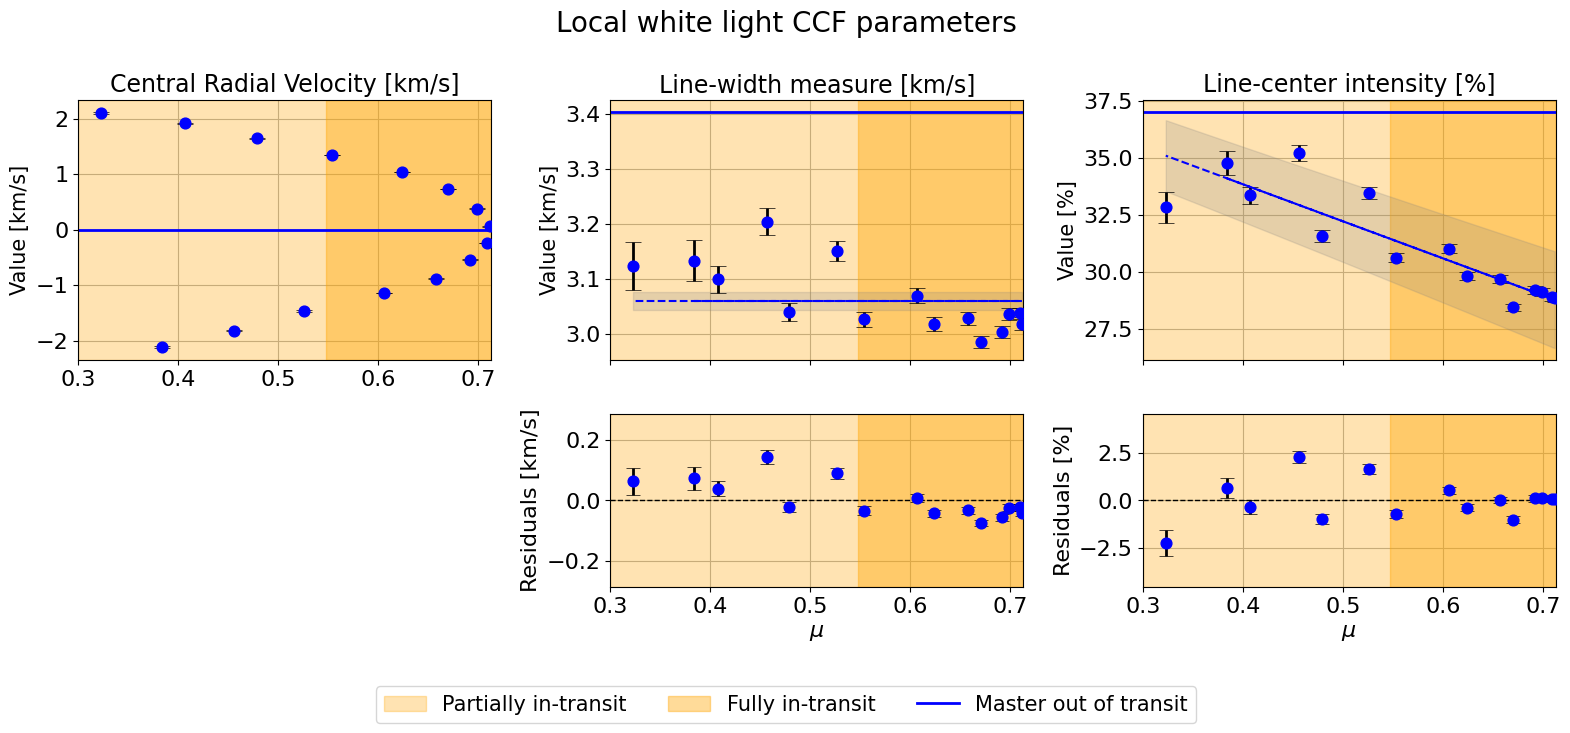

In [11]:
hecate.plot_local_params(indices_final, local_params, master_params, 
                         suptitle=r"Local white light CCF parameters",
                         linear_fit_pairs=[("phases", 0), ("mu", 1), ("mu", 2)])